Plot Figure 1c
--

In [3]:
cd ~/Pythons/

/home/users/guicha/Pythons


In [12]:
import sys
import os
import argparse
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Circle
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D

from config import IUMFIGDIR
from IUM.read_data.read_data import load_raw_pert_surf_var
from IUM.compute_twb.make_rolling_mean_ctrl import load_rolling_mean_ctrl
from IUM.compute_twb.make_rolling_mean_pert import load_rolling_mean_pert
from IUM.plots.p_config import clim_vars, clim_vars_t, figsize, labelsep

Done
Done
Done
Done


In [13]:
### CST ###

flabs_t = {15: 'z', 25: 'a', 30: 'b', 35: 'c', 50: 'd', 75: 'e', 100: 'f', 125: 'g', 150: 'h'}

var = 'twb'
res = 0.5
value = 0.3
value_pert = 1.
length = 50
u = 4.
env = 'stable'
date = '10010101'
time = 15
window = 3
windstep = 20

if var == 'twb':
    flab = 'c'
elif var == 'hi':
    flab = 'a'  # for Supp Mat

In [14]:
data_udry = load_rolling_mean_ctrl(res=res, variable=var, value=value, u=u, env=env, date=date, window=window)
data_uwet = load_rolling_mean_ctrl(res=res, variable=var, value=value_pert, u=u, env=env, date=date, window=window)

data = load_rolling_mean_pert(res=res, variable=var, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, window=window)

lons = data.longitude.values
lats = data.latitude.values

udata = load_raw_pert_surf_var(res=res, variable='u10', value=value, value_pert=value_pert, length=length, u=u, env=env, date=date).isel(height_10m=0)
udata = udata.rolling(T1HR_MN=window, center=True).mean()
vdata = load_raw_pert_surf_var(res=res, variable='v10', value=value, value_pert=value_pert, length=length, u=u, env=env, date=date).isel(height_10m=0)
vdata = vdata.rolling(T1HR_MN=window, center=True).mean()

udata = udata.interp(longitude_uv=lons, latitude_uv=lats)
vdata = vdata.interp(longitude_uv=lons, latitude_uv=lats)
udata = udata.interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])
vdata = vdata.interp(longitude_uv=lons[::windstep], latitude_uv=lats[::windstep])

times = data.time.values

xs = np.arange(res, 400.+res, res)
ys = xs
xc = (xs[-1] - xs[0]) / 2 + res / 2
yc = (ys[-1] - ys[0]) / 2 + res / 2
xc_r = (xs[-1] - xs[0]) / 2 + res / 2 + length / 4
yc_r = yc

xsm, ysm = np.meshgrid(xs, ys)

r = length / 2

distloc = ( ((xsm - xc) * (xsm - xc)) + ((ysm - yc) * (ysm - yc)) )**.5
disc_mask = np.broadcast_to(distloc <= r, data.shape)   # True in disc

spacemean_udry = data_udry.mean(dim=['latitude', 'longitude'])
spacemean_uwet = data_uwet.mean(dim=['latitude', 'longitude'])
spacemean = data.mean(dim=['latitude', 'longitude'])
timemean = data.mean(dim='time')

pmean = timemean.mean().values

datawet = data.where(disc_mask)
datadry = data.where(~disc_mask)
datawet_spacemean = datawet.mean(dim=['latitude', 'longitude'])

timemean_wet = datawet_spacemean.mean(dim='time')

umean = udata.mean(dim='T1HR_MN')
vmean = vdata.mean(dim='T1HR_MN')

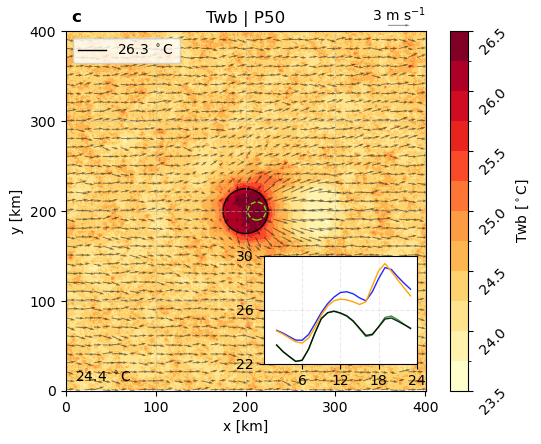

In [15]:
ts = np.arange(len(spacemean)) + 1
xtcks2 = np.arange(6, 24+6, 6)
xtlbs2 = xtcks2

if var == 'twb':
    var_ = 'Twb'
    ylims = (22., 30.)
    ytcks2 = [22., 26., 30.]
elif var == 'hi':
    var_ = 'HI'
    ylims = (22., 50.)
    ytcks2 = np.arange(22., 50.+4, 4)

cmap = plt.get_cmap('YlOrRd')

clim = clim_vars[var]
clim_min = clim[0]
clim_max = clim[1]

bounds = np.arange(clim_min, clim_max+0.25, 0.25)
norm = BoundaryNorm(bounds, cmap.N)  #, extend='both')

circle = Circle((xc, yc), r, facecolor='none', edgecolor='k', linewidth=1, alpha=0.95)
circle_r = Circle((xc_r, yc_r), 10, facecolor='none', edgecolor='chartreuse', ls='--', linewidth=1, alpha=0.85)

xtcks = np.arange(0, 400+100, 100)
ytcks = xtcks

fig, ax0 = plt.subplots()

plt.subplots_adjust(bottom=0.125, top=0.925, left=0.1, wspace=0.01)

p = timemean.plot(ax=ax0, norm=norm, cmap=cmap, add_colorbar=False)
p_uv = ax0.quiver(lons[::windstep], lats[::windstep], umean, vmean, width=0.0025, alpha=0.5, scale=50)

ax0.quiverkey(p_uv, 0.925, 1.015, 3, '3 m s$^{-1}$', labelsep=labelsep)

ax0.text(0.025, 0.025, '%.1f $^\circ$C'%pmean, transform=ax0.transAxes)
ax0.text(0.015, 1.025, flab, weight='bold', fontsize=12, transform=ax0.transAxes)

ax0.add_patch(circle)
ax0.add_patch(circle_r)

ax1 = ax0.inset_axes([0.55, 0.075, 0.425, 0.3])

ax1.plot(ts, spacemean_udry.values, color='g', lw=1., alpha=0.85, label='UDRY')
ax1.plot(ts, spacemean_uwet.values, color='b', lw=1., alpha=0.85, label='UWET')
ax1.plot(ts, spacemean.values, color='k', lw=1., alpha=0.85, label='All')
ax1.plot(ts, datawet_spacemean.values, lw=1., color='orange', label='Patch')

ax0.set_aspect('equal')
ax0.set_xticks(xtcks)
ax0.set_xlabel('x [km]')
ax0.set_yticks(ytcks)
ax0.set_ylabel('y [km]')
ax0.grid(True, alpha=0.5, ls='--')
ax0.set_title('%s | P%i'%(var_, length))
ax1.set_xticks(xtcks2)
ax1.set_xticklabels(xtlbs2)
ax1.set_xlim(0, 24)
ax1.set_ylim(ylims)
ax1.set_yticks(ytcks2)
ax1.grid(True, ls='--', alpha=0.25)

lwet = Line2D([0, 0.5], [0, 0], color='k', ls='-', lw=1.)
hs = [lwet]
ls = ['%.1f $^\circ$C'%timemean_wet.values]

ax0.legend(handles=hs, labels=ls, loc='upper left')

cb = plt.colorbar(p, norm=norm, cmap=cmap, orientation='vertical', label='%s [$^\circ$C]'%var_, shrink=1., pad=0.05)
cb.ax.tick_params(rotation=45)

fig.set_size_inches(6., 4.5)